In [ ]:
# Cell 1 - Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# Cell 2 — Loading Dataset
df = pd.read_csv('../data/raw/telco_churn.csv')

print(f'Rows(Customers): {df.shape[0]}')
print(f'Columns (Features): {df.shape[1]}')

display(df.head())

Rows(Customers): 7043
Columns (Features): 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Cell 3 — First Look at Raw Data
print("Dataset Info:")
df.info()

print('\n')

print('Unique values per column:')
display(df.nunique())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

Churn
No     5174
Yes    1869
Name: count, dtype: int64
No : 5174 Customers (73.5%)
Yes : 1869 Customers (26.5%)



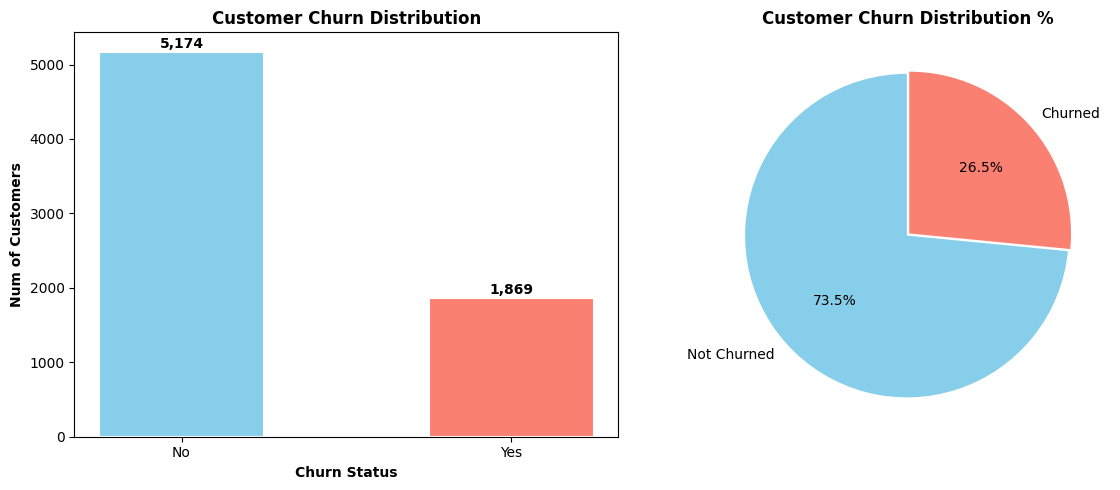

In [ ]:
# Cell 4 — Quick EDA: Class Imbalance
churn_counts = df['Churn'].value_counts()
print(churn_counts)

for value, count in churn_counts.items():

    percentage = (count / (len(df))) * 100
    print(f'{value} : {count} Customers ({percentage:.1f}%)')

print()

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

#Bar Chart
bars = ax[0].bar(churn_counts.index, 
                 churn_counts.values, 
                 color = ['skyblue', 'salmon'],
                 edgecolor = 'white',
                 linewidth = 1.5, 
                 width = 0.5)

for bar, value in zip(bars, churn_counts.values):
    ax[0].text(bar.get_x() + bar.get_width()/2  ,
               bar.get_height() + 50,
               f'{value:,}',
               ha = 'center',
               fontweight = 'bold',
               fontsize = 10)
    
ax[0].set_title('Customer Churn Distribution', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('Churn Status', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Num of Customers', fontsize = 10, fontweight = 'bold')

#Pie Chart
ax[1].pie(churn_counts.values, 
          labels = ['Not Churned', 'Churned'],
          autopct = '%1.1f%%',
          colors = ['skyblue', 'salmon'],
          startangle = 90,  
          explode = (0.01, 0.01)) 

ax[1].set_title('Customer Churn Distribution %', fontsize = 12, fontweight = 'bold')

plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Cell 5 — Complete Missing Value Audit
print("COMPLETE MISSING VALUE AUDIT")
print("=" * 55)

# Checking True NaN values
print("\n Checking True NaN Missing Values")
print("─" * 40)
true_missing = df.isnull().sum()
true_missing_cols = true_missing[true_missing > 0]
if len(true_missing_cols) == 0:
    print("No true NaN missing values found!")
else:
    print(true_missing_cols)

# Checking Disguised missing values in text columns
print("\nChecking Disguised Missing in Text Columns")
print("─" * 40)
text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    disguised = df[col].str.strip().eq('').sum()
    placeholders = df[col].str.lower().isin(
        ['n/a', 'na', 'none', 'unknown', 'null', '?', '-']
    ).sum()
    total = disguised + placeholders
    if total > 0:
        print(f"{col}: {total} disguised missing values")
    else:
        print(f"{col}: Clean")

# Checking Zeros in numerical columns
print("\nChecking Zero Values in Numerical Columns")
print("─" * 40)
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"ℹ{col}: {zero_count} zeros "
              f"(verify if 0 is valid here)")

print("\nSUMMARY")
print("─" * 40)
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"True NaN: {df.isnull().sum().sum()}")


COMPLETE MISSING VALUE AUDIT

 Checking True NaN Missing Values
────────────────────────────────────────
No true NaN missing values found!

Checking Disguised Missing in Text Columns
────────────────────────────────────────
customerID: Clean
gender: Clean
Partner: Clean
Dependents: Clean
PhoneService: Clean
MultipleLines: Clean
InternetService: Clean
OnlineSecurity: Clean
OnlineBackup: Clean
DeviceProtection: Clean
TechSupport: Clean
StreamingTV: Clean
StreamingMovies: Clean
Contract: Clean
PaperlessBilling: Clean
PaymentMethod: Clean
TotalCharges: 11 disguised missing values
Churn: Clean

Checking Zero Values in Numerical Columns
────────────────────────────────────────
ℹSeniorCitizen: 5901 zeros (verify if 0 is valid here)
ℹtenure: 11 zeros (verify if 0 is valid here)

SUMMARY
────────────────────────────────────────
Total rows: 7043
Total columns: 21
True NaN: 0


In [ ]:
# Cell 6 — Basic Statistics
print("NUMERICAL COLUMNS SUMMARY:")
print("─" * 40)

display(df.describe().round(2))

print("\nCATEGORICAL COLUMNS SUMMARY:")
print("─" * 40)

display(df.describe(include='object'))

NUMERICAL COLUMNS SUMMARY:
────────────────────────────────────────


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75



CATEGORICAL COLUMNS SUMMARY:
────────────────────────────────────────


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
# Cell 7 — Fix TotalCharges Data Type
print("BEFORE FIXING:")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

# Find disguised missing values
problem_rows = df[df['TotalCharges'].str.strip() == '']
print(f"Rows with empty TotalCharges: {len(problem_rows)}")

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("\nAFTER FIXING:")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"NaN values created: {df['TotalCharges'].isnull().sum()}")

BEFORE FIXING:
TotalCharges dtype: object
Rows with empty TotalCharges: 11

AFTER FIXING:
TotalCharges dtype: float64
NaN values created: 11


In [ ]:
# Cell 8 — Drop Rows with Missing TotalCharges
print(f"Rows BEFORE dropping: {len(df)}")

df = df.dropna(subset=['TotalCharges'])

print(f"Rows AFTER dropping:  {len(df)}")
print(f"Rows removed: {7043 - len(df)}")
print(f"Missing values now: {df.isnull().sum().sum()}")

Rows BEFORE dropping: 7043
Rows AFTER dropping:  7032
Rows removed: 11
Missing values now: 0


In [ ]:
# Cell 9 — Drop Unnecessary Columns
print(f"Shape before: {df.shape}")

df = df.drop('customerID', axis=1)

print(f"Shape after:  {df.shape}")
print("customerID column removed ")

Shape before: (7032, 21)
Shape after:  (7032, 20)
customerID column removed 


In [ ]:
# Cell 10 — Encode Target Column
print(f"Before: {df['Churn'].unique()}")

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"After:  {df['Churn'].unique()}")
print(f"dtype:  {df['Churn'].dtype}")

Before: ['No' 'Yes']
After:  [0 1]
dtype:  int64


In [ ]:
# Cell 11 — One-Hot Encode Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Text columns to encode: {len(categorical_cols)}")
print(categorical_cols)

print(f"\nShape before: {df.shape}")

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(f"Shape after:  {df_encoded.shape}")
print(f"New columns:  {df_encoded.shape[1] - df.shape[1]}")

Text columns to encode: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape before: (7032, 20)
Shape after:  (7032, 31)
New columns:  11


In [ ]:
# Cell 12 — Saving Cleaned Dataset
df_encoded.to_csv(
    '../data/processed/telco_churn_cleaned.csv',
    index=False
)

print(f"Final shape: {df_encoded.shape}")

Final shape: (7032, 31)


In [ ]:
# Cell 13 — Final Cleaning Verification

print("CLEANING VERIFICATION:")
print("─" * 40)
print(f"Rows:                  {df_encoded.shape[0]}")
print(f"Columns:               {df_encoded.shape[1]}")
print(f"Missing values:        {df_encoded.isnull().sum().sum()}")
print(f"Churn values:          {df_encoded['Churn'].unique()}")
print(f"Text columns left:     "
      f"{len(df_encoded.select_dtypes(include='object').columns)}")

# Checking specific expected values
assert df_encoded.shape[0] == 7032, "❌ Row count wrong!"
assert df_encoded.shape[1] < 100,   "❌ Too many columns!"
assert df_encoded.isnull().sum().sum() == 0, "❌ Missing values!"
assert df_encoded['Churn'].nunique() == 2, "❌ Churn not encoded!"

print("\nAll checks passed")

CLEANING VERIFICATION:
────────────────────────────────────────
Rows:                  7032
Columns:               31
Missing values:        0
Churn values:          [0 1]
Text columns left:     0

All checks passed
